# Turn-gate strategy sweep — what's the fastest way to reach a target?

Robot at the origin facing north, target 80 cm away at angle **θ** off the nose.
We sweep three parameters and measure **time to reach** (first moment the TRUE
pose is within 5 cm of the target — the robot passes ~1 mm from it, so this is a
fair arrival time, ignoring overshoot):

1. **θ** (target angle): 0…180° in 10° steps (19 values).
2. **turn gate G**: 0…180° in 5° steps (37 values).
3. **strategy**: `to_gate` (turn in place only until the bearing reaches the
   gate, then arc) vs `complete` (once the gate trips, keep turning until you
   fully face the target, then drive straight).

Slip and encoder noise are **off** — deterministic, no error, pure strategy timing.

In [1]:
%matplotlib inline
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")
import math, subprocess, pathlib, sys, time as systime
import matplotlib.pyplot as plt
import numpy as np

CWD = pathlib.Path.cwd()
REPO = pathlib.Path.cwd()
while not (REPO / "host_tests").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
HOST = REPO / "host"
if str(HOST) not in sys.path:
    sys.path.insert(0, str(HOST))
LIB = REPO / "host_tests" / "build"
if not LIB.exists():
    subprocess.run(["cmake", "-S", str(REPO / "host_tests"), "-B", str(LIB)], cwd=REPO, check=True)
print("Building libfirmware_host..."); sys.stdout.flush()
subprocess.run(["cmake", "--build", str(LIB), "--", "-j4"], cwd=REPO, check=True)
print("Build OK")
from robot_radio.io.sim_conn import SimConnection

R_MM, SPEED, DT, MAX_MS, REACH = 800, 200, 50, 20000, 50


def trial(theta_deg, gate_eff):
    """Run G with firmware turnGate=gate_eff; return time-to-reach (ms) or None.
    Slip + noise OFF -> deterministic. 'reach' = TRUE pose within REACH mm."""
    a = math.radians(theta_deg)
    tx, ty = R_MM * math.cos(a), R_MM * math.sin(a)
    c = SimConnection(); c.connect()
    c.set_slip(0.0, 0.0); c.set_encoder_noise(0.0)
    c.send("SET sTimeout=60000"); c.send(f"SET turnGate={gate_eff}")
    c.set_enc(0.0, 0.0); c.tick(50)
    c.send(f"G {int(round(tx))} {int(round(ty))} {SPEED}")
    t = 0; t_reach = None
    while t < MAX_MS:
        c.tick(DT); t += DT
        p = c.get_exact_pose()
        if math.hypot(p["x"] - tx, p["y"] - ty) <= REACH:
            t_reach = t; break
    c.disconnect()
    return t_reach


def gate_eff_for(theta, G, mode):
    """Map (gate G, strategy) to the firmware turnGate value.
    - not triggered (theta<=G): pure arc, gate 181 (never pre-rotate).
    - to_gate: pre-rotate to G then arc (floor 2deg; gate 0 would spin forever).
    - complete: turn until ~facing (2deg) then straight."""
    if theta <= G:
        return 181
    return max(G, 2) if mode == "to_gate" else 2


ANGLES = list(range(0, 181, 10))   # 19
GATES  = list(range(0, 181, 5))    # 37
MODES  = ["to_gate", "complete"]
print(f"grid: {len(ANGLES)} angles x {len(GATES)} gates x {len(MODES)} modes = "
      f"{len(ANGLES) * len(GATES) * len(MODES)} trials")

Building libfirmware_host...


[100%] Built target firmware_host


Build OK
grid: 19 angles x 37 gates x 2 modes = 1406 trials


In [2]:
# Run the full sweep.
data = {m: {} for m in MODES}
t0 = systime.time(); n = 0
for m in MODES:
    for th in ANGLES:
        for G in GATES:
            data[m][(th, G)] = trial(th, gate_eff_for(th, G, m))
            n += 1
    print(f"  {m} done ({n} trials, {systime.time() - t0:.1f}s)")
print(f"\n{n} trials in {systime.time() - t0:.1f}s")

  to_gate done (703 trials, 3.1s)


  complete done (1406 trials, 6.5s)

1406 trials in 6.5s


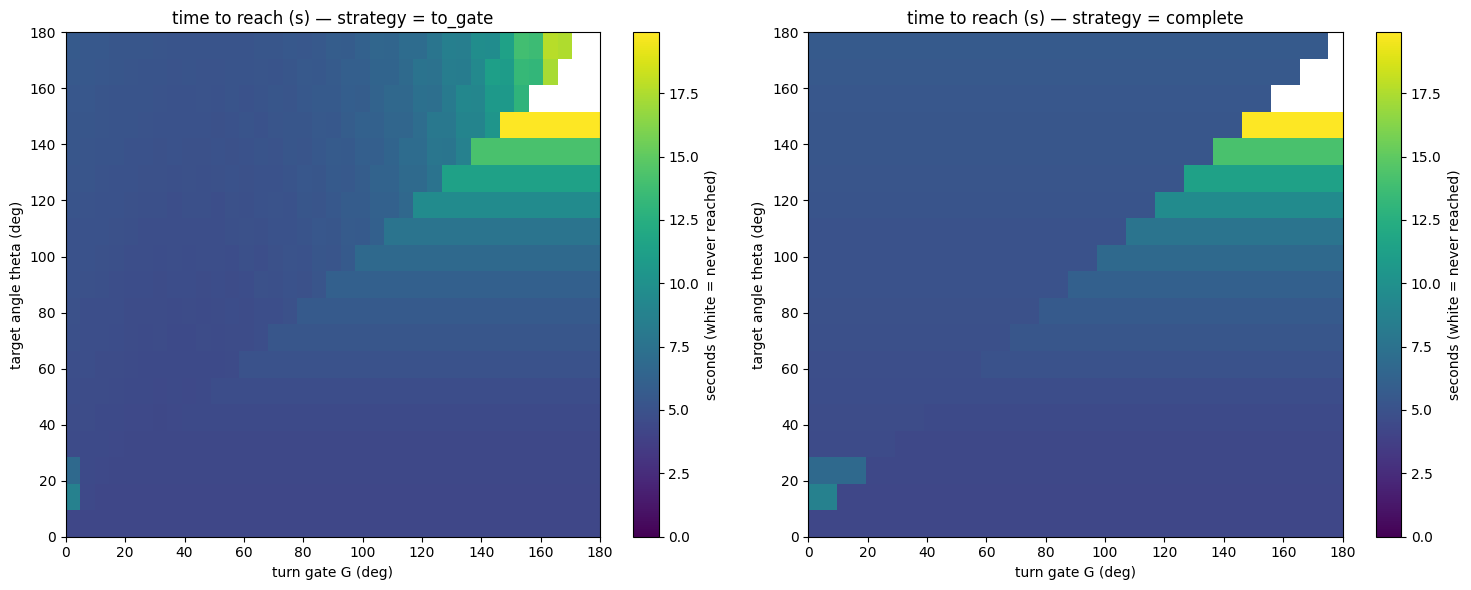

In [3]:
# Heatmaps: time-to-reach (s) vs (theta, gate) for each strategy.
def grid_of(mode):
    g = np.full((len(ANGLES), len(GATES)), np.nan)
    for i, th in enumerate(ANGLES):
        for j, G in enumerate(GATES):
            tr = data[mode][(th, G)]
            g[i, j] = np.nan if tr is None else tr / 1000.0
    return g

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
vmax = np.nanmax([np.nanmax(grid_of(m)) for m in MODES])
for ax, m in zip(axes, MODES):
    g = grid_of(m)
    im = ax.imshow(g, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=vmax,
                   extent=[GATES[0], GATES[-1], ANGLES[0], ANGLES[-1]])
    ax.set_title(f"time to reach (s) — strategy = {m}")
    ax.set_xlabel("turn gate G (deg)"); ax.set_ylabel("target angle theta (deg)")
    fig.colorbar(im, ax=ax, label="seconds (white = never reached)")
plt.tight_layout(); plt.show()

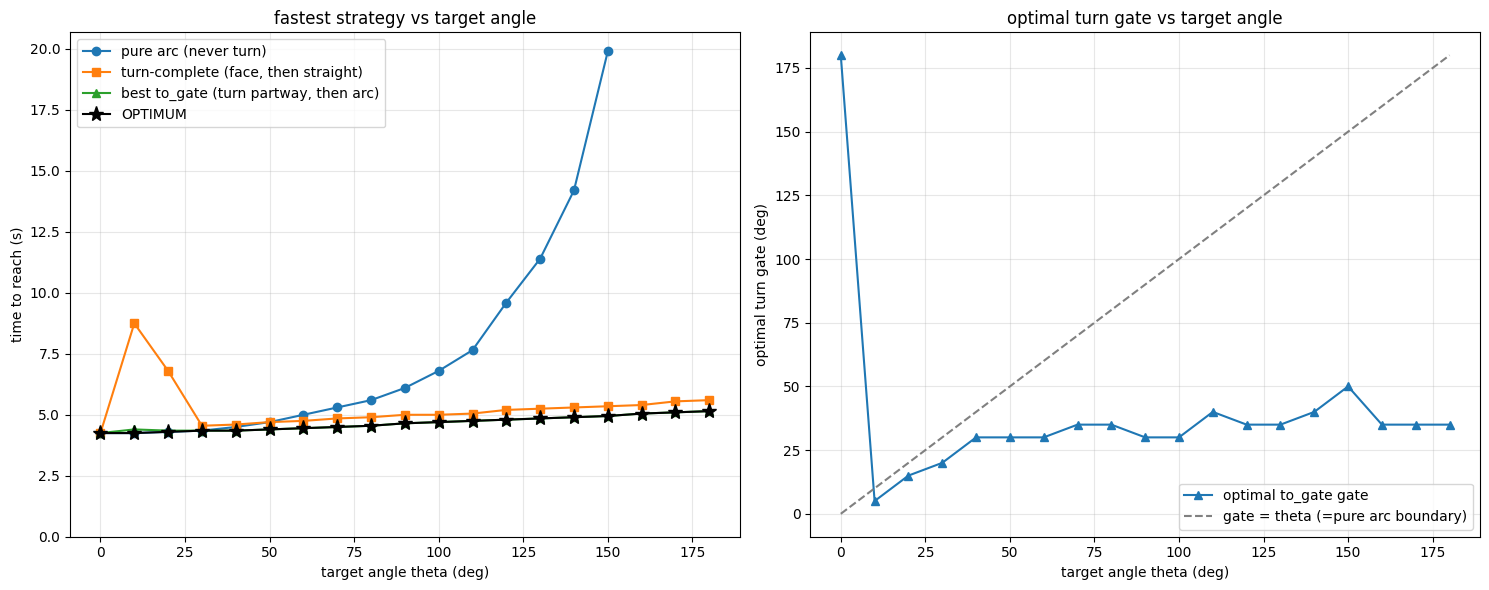

theta | arc(s) complete(s) bestToGate(s)@gate | OPTIMUM
    0 |  4.25     4.25      4.25 @180   | arc
   10 |  4.25     8.75      4.40 @  5   | arc
   20 |  4.30     6.80      4.35 @ 15   | arc
   30 |  4.35     4.55      4.35 @ 20   | arc
   40 |  4.50     4.60      4.35 @ 30   | to_gate@30
   50 |  4.70     4.70      4.40 @ 30   | to_gate@30
   60 |  5.00     4.75      4.45 @ 30   | to_gate@30
   70 |  5.30     4.85      4.50 @ 35   | to_gate@35
   80 |  5.60     4.90      4.55 @ 35   | to_gate@35
   90 |  6.10     5.00      4.65 @ 30   | to_gate@30
  100 |  6.80     5.00      4.70 @ 30   | to_gate@30
  110 |  7.65     5.05      4.75 @ 40   | to_gate@40
  120 |  9.60     5.20      4.80 @ 35   | to_gate@35
  130 | 11.40     5.25      4.85 @ 35   | to_gate@35
  140 | 14.20     5.30      4.90 @ 40   | to_gate@40
  150 | 19.90     5.35      4.95 @ 50   | to_gate@50
  160 |   inf     5.40      5.05 @ 35   | to_gate@35
  170 |   inf     5.55      5.10 @ 35   | to_gate@35
  180 |   inf     

In [4]:
# Per-angle optimum: compare pure-arc vs turn-complete vs best to_gate.
def t_s(mode, th, G):
    v = data[mode][(th, G)]
    return np.inf if v is None else v / 1000.0

arc_t, comp_t, tog_t, tog_g, best_t, best_lbl = [], [], [], [], [], []
for th in ANGLES:
    # pure arc: any G >= theta gives gate_eff 181 (take the largest gate)
    arc = t_s("to_gate", th, GATES[-1])
    # turn-complete: smallest gate that trips (G < theta); else = arc (theta=0)
    trip = [G for G in GATES if th > G]
    comp = t_s("complete", th, trip[0]) if trip else arc
    # best to_gate over all gates that trip
    if trip:
        cand = [(t_s("to_gate", th, G), G) for G in trip]
        tg, gg = min(cand)
    else:
        tg, gg = arc, GATES[-1]
    arc_t.append(arc); comp_t.append(comp); tog_t.append(tg); tog_g.append(gg)
    opts = {"arc": arc, "complete": comp, f"to_gate@{gg}": tg}
    lbl = min(opts, key=opts.get)
    best_t.append(opts[lbl]); best_lbl.append(lbl)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(ANGLES, arc_t, 'o-', label="pure arc (never turn)")
ax1.plot(ANGLES, comp_t, 's-', label="turn-complete (face, then straight)")
ax1.plot(ANGLES, tog_t, '^-', label="best to_gate (turn partway, then arc)")
ax1.plot(ANGLES, best_t, 'k*-', ms=11, label="OPTIMUM")
ax1.set_xlabel("target angle theta (deg)"); ax1.set_ylabel("time to reach (s)")
ax1.set_title("fastest strategy vs target angle"); ax1.grid(alpha=0.3); ax1.legend()
ax1.set_ylim(0, None)

ax2.plot(ANGLES, tog_g, '^-', label="optimal to_gate gate")
ax2.set_xlabel("target angle theta (deg)"); ax2.set_ylabel("optimal turn gate (deg)")
ax2.set_title("optimal turn gate vs target angle"); ax2.grid(alpha=0.3)
ax2.plot(ANGLES, ANGLES, '--', color='gray', label="gate = theta (=pure arc boundary)")
ax2.legend()
plt.tight_layout(); plt.show()

print("theta | arc(s) complete(s) bestToGate(s)@gate | OPTIMUM")
for i, th in enumerate(ANGLES):
    print(f"{th:5d} | {arc_t[i]:5.2f}   {comp_t[i]:6.2f}    {tog_t[i]:6.2f} @{tog_g[i]:3d}   | {best_lbl[i]}")

In [5]:
# Derive a single recommended decision rule from the optimum column.
print("=== Optimal strategy summary ===\n")
# Where does pure-arc stop being optimal?
arc_opt = [th for th, l in zip(ANGLES, best_lbl) if l == "arc"]
turn_opt = [th for th, l in zip(ANGLES, best_lbl) if l != "arc"]
if arc_opt:
    print(f"Pure ARC is fastest for theta <= {max(arc_opt)}deg.")
if turn_opt:
    print(f"Turning first wins for theta >= {min(turn_opt)}deg:")
    for th in turn_opt:
        i = ANGLES.index(th)
        print(f"   theta={th:3d}: {best_lbl[i]}  ({best_t[i]:.2f}s; "
              f"arc would be {arc_t[i]:.2f}s, complete {comp_t[i]:.2f}s)")
# Is turn-complete ever beaten by a partial to_gate?
partial_wins = [th for th, l in zip(ANGLES, best_lbl) if l.startswith("to_gate")]
print(f"\nPartial turn-then-arc (to_gate) is strictly best at: "
      f"{partial_wins if partial_wins else 'never — arc or complete always win'}")

=== Optimal strategy summary ===

Pure ARC is fastest for theta <= 30deg.
Turning first wins for theta >= 40deg:
   theta= 40: to_gate@30  (4.35s; arc would be 4.50s, complete 4.60s)
   theta= 50: to_gate@30  (4.40s; arc would be 4.70s, complete 4.70s)
   theta= 60: to_gate@30  (4.45s; arc would be 5.00s, complete 4.75s)
   theta= 70: to_gate@35  (4.50s; arc would be 5.30s, complete 4.85s)
   theta= 80: to_gate@35  (4.55s; arc would be 5.60s, complete 4.90s)
   theta= 90: to_gate@30  (4.65s; arc would be 6.10s, complete 5.00s)
   theta=100: to_gate@30  (4.70s; arc would be 6.80s, complete 5.00s)
   theta=110: to_gate@40  (4.75s; arc would be 7.65s, complete 5.05s)
   theta=120: to_gate@35  (4.80s; arc would be 9.60s, complete 5.20s)
   theta=130: to_gate@35  (4.85s; arc would be 11.40s, complete 5.25s)
   theta=140: to_gate@40  (4.90s; arc would be 14.20s, complete 5.30s)
   theta=150: to_gate@50  (4.95s; arc would be 19.90s, complete 5.35s)
   theta=160: to_gate@35  (5.05s; arc would 